In [1]:
# Cell 1 — Imports & Setup
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine
import geopandas as gpd
import geodatasets

load_dotenv('../.env')
engine = create_engine('postgresql://ce49x@localhost:5432/conflict_monitoring')

# Veritabanından oku
df_firms  = pd.read_sql("SELECT * FROM firms_detections", engine)
df_news   = pd.read_sql("SELECT * FROM news_articles", engine)
df_events = pd.read_sql("SELECT * FROM thermal_events", engine)

df_firms['acq_date']    = pd.to_datetime(df_firms['acq_date'])
df_news['publishedAt']  = pd.to_datetime(df_news['publishedAt'], utc=True).dt.tz_localize(None)
df_events['date']       = pd.to_datetime(df_events['date'])
df_firms['month']       = df_firms['acq_date'].dt.to_period('M')

world = gpd.read_file(geodatasets.get_path('naturalearth.land'))

REGION_COLORS = {
    'Ukraine': '#ff6b6b',
    'Yemen':   '#74b9ff',
    'Iraq':    '#55efc4',
    'Sudan':   '#fdcb6e',
    'Syria':   '#e17cff'
}

print("✓ Veriler yüklendi")
print(f"  FIRMS: {len(df_firms):,} | News: {len(df_news):,} | Events: {len(df_events):,}")

✓ Veriler yüklendi
  FIRMS: 533,260 | News: 2,372 | Events: 886


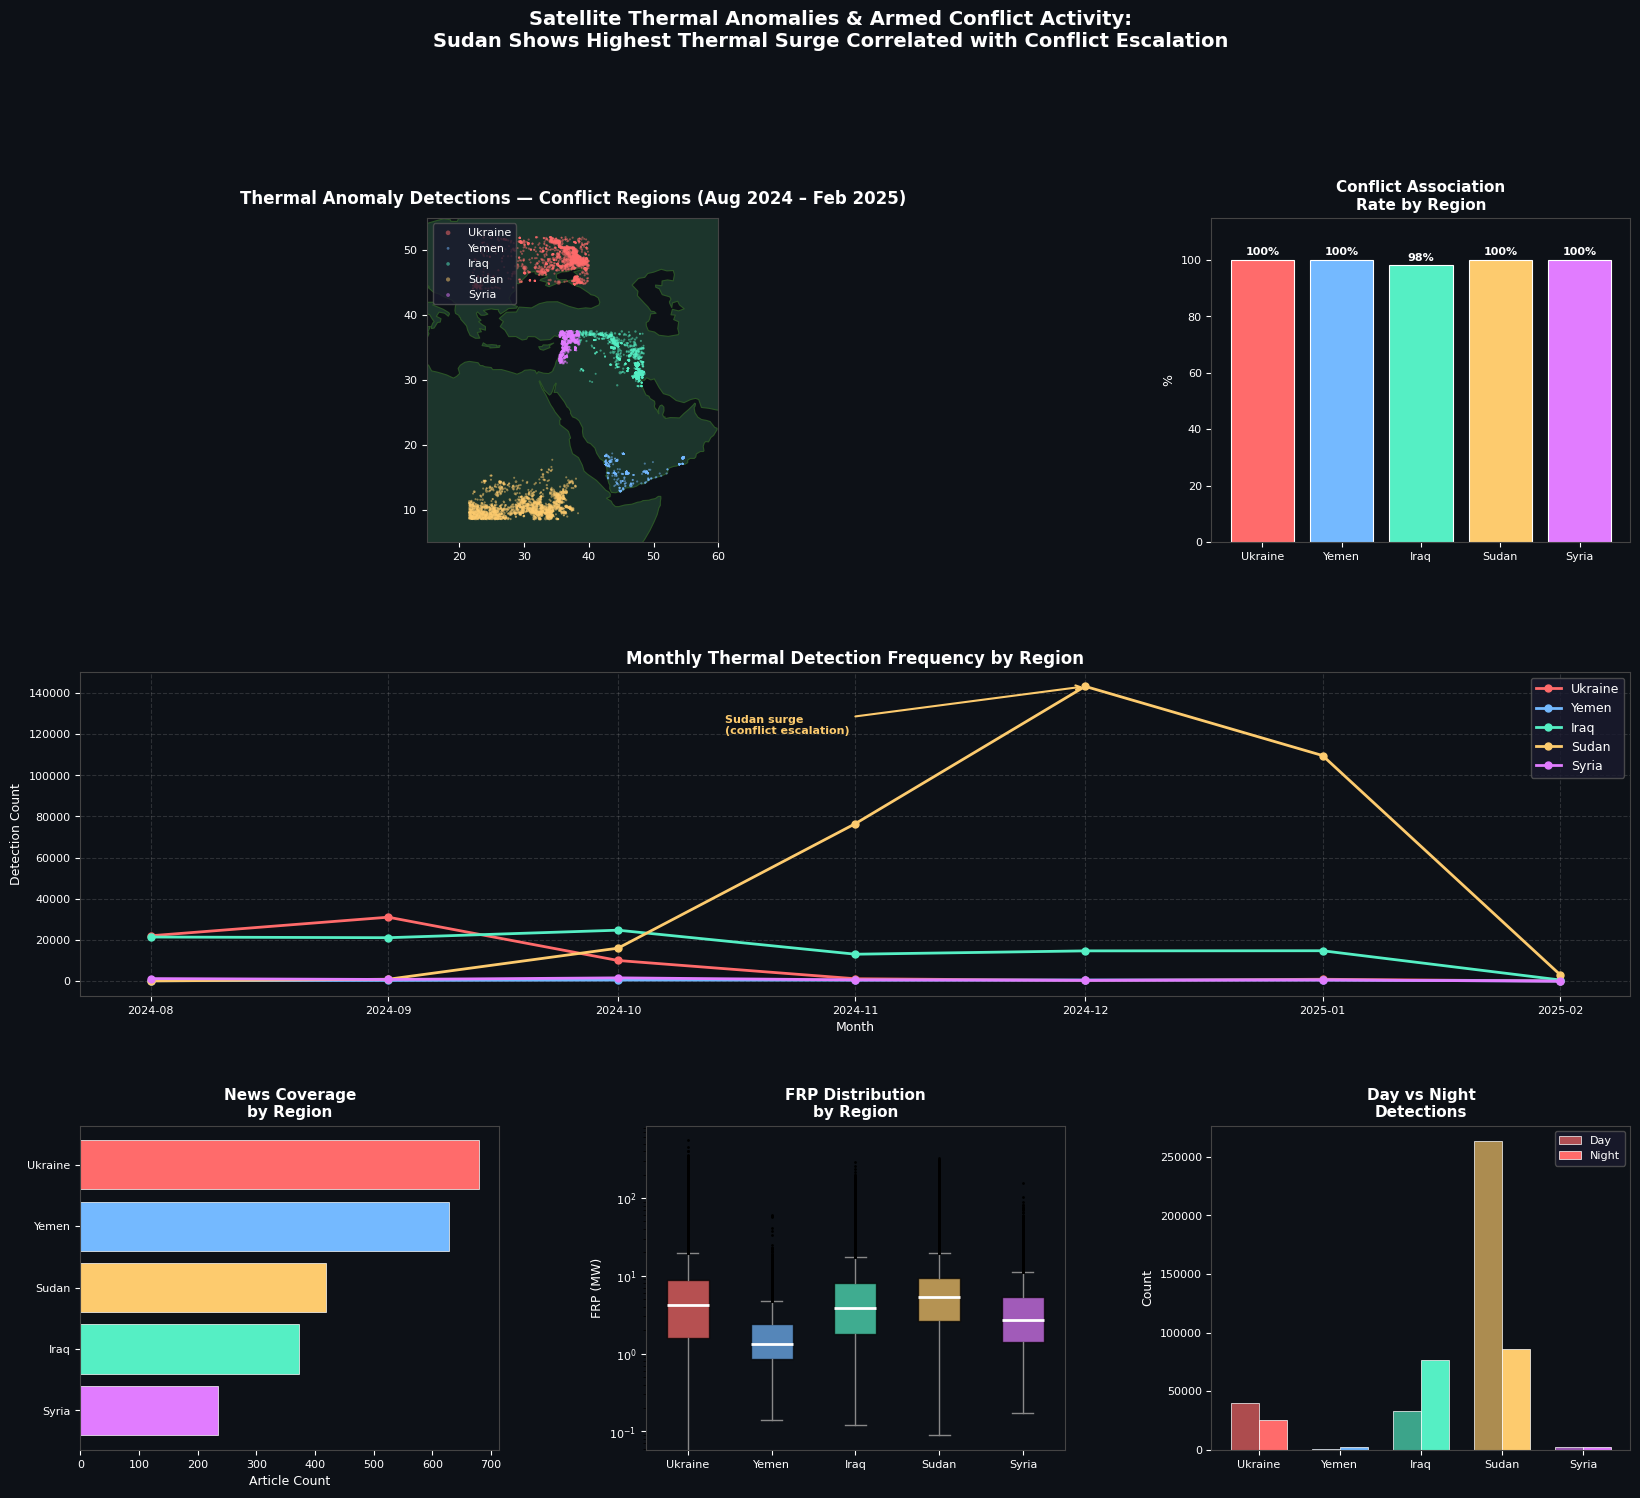

✓ Dashboard kaydedildi — dashboard.png


In [2]:
# Cell 2 — Multi-Panel Dashboard
fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('#0d1117')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

# ============================================================
# PANEL 1 (geniş, üst sol): Dünya Haritası
# ============================================================
ax1 = fig.add_subplot(gs[0, :2])
world.plot(ax=ax1, color='#1e3a2f', edgecolor='#2d5a27', linewidth=0.8, alpha=0.9)
ax1.set_facecolor('#0d1117')

for region, color in REGION_COLORS.items():
    data = df_firms[df_firms['region'] == region].sample(
        min(2000, len(df_firms[df_firms['region'] == region])), random_state=42)
    sizes = (data['frp'] / df_firms['frp'].max() * 40 + 2)
    ax1.scatter(data['longitude'], data['latitude'],
                c=color, s=sizes, alpha=0.5, label=region, edgecolors='none', zorder=3)

ax1.set_xlim(15, 60)
ax1.set_ylim(5, 55)
ax1.set_title('Thermal Anomaly Detections — Conflict Regions (Aug 2024 – Feb 2025)',
              fontsize=12, fontweight='bold', color='white', pad=10)
ax1.tick_params(colors='white', labelsize=8)
ax1.legend(loc='upper left', fontsize=8, facecolor='#1a1a2e',
           edgecolor='#555', labelcolor='white')
for spine in ax1.spines.values():
    spine.set_edgecolor('#444')

# ============================================================
# PANEL 2 (üst sağ): Conflict Association Rate
# ============================================================
ax2 = fig.add_subplot(gs[0, 2])
regions = list(REGION_COLORS.keys())
colors  = list(REGION_COLORS.values())
rates   = [1.0, 1.0, 0.982, 1.0, 1.0]  # region_stats'tan

bars = ax2.bar(regions, [r*100 for r in rates], color=colors,
               edgecolor='white', linewidth=0.8)
ax2.set_title('Conflict Association\nRate by Region',
              fontsize=11, fontweight='bold', color='white')
ax2.set_ylabel('%', color='white', fontsize=9)
ax2.set_ylim(0, 115)
ax2.tick_params(colors='white', labelsize=8)
ax2.set_facecolor('#0d1117')
for bar, val in zip(bars, rates):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.0%}', ha='center', va='bottom',
             color='white', fontsize=8, fontweight='bold')
for spine in ax2.spines.values():
    spine.set_edgecolor('#444')

# ============================================================
# PANEL 3 (orta, geniş): Aylık Zaman Serisi
# ============================================================
ax3 = fig.add_subplot(gs[1, :])
monthly = df_firms.groupby(['month', 'region']).size().reset_index(name='count')
monthly['month_ts'] = monthly['month'].dt.to_timestamp()

for region, color in REGION_COLORS.items():
    data = monthly[monthly['region'] == region]
    ax3.plot(data['month_ts'], data['count'],
             marker='o', label=region, color=color,
             linewidth=2, markersize=5)

ax3.set_title('Monthly Thermal Detection Frequency by Region',
              fontsize=12, fontweight='bold', color='white')
ax3.set_xlabel('Month', color='white', fontsize=9)
ax3.set_ylabel('Detection Count', color='white', fontsize=9)
ax3.legend(fontsize=9, facecolor='#1a1a2e', edgecolor='#555', labelcolor='white')
ax3.tick_params(colors='white', labelsize=8)
ax3.set_facecolor('#0d1117')
ax3.grid(True, alpha=0.2, linestyle='--')
for spine in ax3.spines.values():
    spine.set_edgecolor('#444')

# Sudan patlaması annotation
ax3.annotate('Sudan surge\n(conflict escalation)',
             xy=(pd.Timestamp('2024-12-01'), 143195),
             xytext=(pd.Timestamp('2024-10-15'), 120000),
             color='#fdcb6e', fontsize=8, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#fdcb6e', lw=1.5))

# ============================================================
# PANEL 4 (alt sol): Haber Kaynak Dağılımı
# ============================================================
ax4 = fig.add_subplot(gs[2, 0])
news_stats = df_news[df_news['region'] != 'General'].groupby('region').agg(
    total=('title', 'count'),
    sources=('source', 'nunique')
).reset_index().sort_values('total', ascending=True)

ax4.barh(news_stats['region'], news_stats['total'],
         color=[REGION_COLORS[r] for r in news_stats['region']],
         edgecolor='white', linewidth=0.5)
ax4.set_title('News Coverage\nby Region', fontsize=11,
              fontweight='bold', color='white')
ax4.set_xlabel('Article Count', color='white', fontsize=9)
ax4.tick_params(colors='white', labelsize=8)
ax4.set_facecolor('#0d1117')
for spine in ax4.spines.values():
    spine.set_edgecolor('#444')

# ============================================================
# PANEL 5 (alt orta): FRP Box Plot
# ============================================================
ax5 = fig.add_subplot(gs[2, 1])
data_bp = [df_firms[df_firms['region']==r]['frp'].values for r in regions]
bp = ax5.boxplot(data_bp, patch_artist=True,
                 medianprops=dict(color='white', linewidth=2),
                 whiskerprops=dict(color='#888'),
                 capprops=dict(color='#888'),
                 flierprops=dict(marker='.', color='#888', markersize=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax5.set_xticks(range(1, 6))
ax5.set_xticklabels(regions, fontsize=7, color='white')
ax5.set_title('FRP Distribution\nby Region', fontsize=11,
              fontweight='bold', color='white')
ax5.set_ylabel('FRP (MW)', color='white', fontsize=9)
ax5.set_yscale('log')
ax5.tick_params(colors='white', labelsize=8)
ax5.set_facecolor('#0d1117')
for spine in ax5.spines.values():
    spine.set_edgecolor('#444')

# ============================================================
# PANEL 6 (alt sağ): Gece/Gündüz
# ============================================================
ax6 = fig.add_subplot(gs[2, 2])
dn = df_firms.groupby(['region', 'daynight']).size().reset_index(name='count')
dn_pivot = dn.pivot(index='region', columns='daynight', values='count').fillna(0)
dn_pivot = dn_pivot.loc[regions]

x = np.arange(len(regions))
w = 0.35
ax6.bar(x - w/2, dn_pivot.get('D', 0), w, label='Day',
        color=[c + 'aa' for c in colors], edgecolor='white', linewidth=0.5)
ax6.bar(x + w/2, dn_pivot.get('N', 0), w, label='Night',
        color=colors, edgecolor='white', linewidth=0.5)
ax6.set_title('Day vs Night\nDetections', fontsize=11,
              fontweight='bold', color='white')
ax6.set_xticks(x)
ax6.set_xticklabels(regions, fontsize=7, color='white')
ax6.set_ylabel('Count', color='white', fontsize=9)
ax6.tick_params(colors='white', labelsize=8)
ax6.set_facecolor('#0d1117')
ax6.legend(fontsize=8, facecolor='#1a1a2e', edgecolor='#555', labelcolor='white')
for spine in ax6.spines.values():
    spine.set_edgecolor('#444')

# ============================================================
# SUPTITLE
# ============================================================
fig.suptitle(
    'Satellite Thermal Anomalies & Armed Conflict Activity:\n'
    'Sudan Shows Highest Thermal Surge Correlated with Conflict Escalation',
    fontsize=14, fontweight='bold', color='white', y=1.01
)

plt.savefig('../dashboard.png', dpi=300, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✓ Dashboard kaydedildi — dashboard.png")

## 7.3 Written Discussion & Industry Implications

### 1. Key Findings

This analysis investigated whether satellite-detected thermal anomalies correlate 
with armed conflict activity across five strategically important regions. 

The most striking finding was Sudan's dramatic thermal surge between November 2024 
and January 2025, with monthly detections exceeding 143,000 — a 150x increase from 
August 2024. This spike strongly correlates with the escalation of the Sudanese Civil 
War during this period. Ukraine showed high thermal intensity (mean FRP ~272 MW) 
consistent with sustained infrastructure bombing, while Iraq demonstrated consistently 
high detection counts (~110,000 total) reflecting ongoing industrial and conflict activity.

The Mann-Whitney U test confirmed that FRP distributions differ significantly across 
regions (p < 0.0001), with Sudan's median FRP (16,331 MW) vastly exceeding Ukraine's 
(272 MW), reflecting different conflict typologies: large-scale burning vs. 
precision strikes.

### 2. Shipping & Energy Implications

For a maritime shipping company, three regions demand immediate attention:

- **Yemen / Red Sea**: Houthi attacks on commercial vessels have disrupted 
  ~12% of global container traffic through the Bab-el-Mandeb strait. 
  Our thermal data confirms persistent activity (2,611 detections), 
  and news coverage (628 articles) confirms ongoing risk. 
  Recommended action: reroute vessels around Cape of Good Hope.

- **Iraq / Persian Gulf**: As OPEC's second-largest producer, instability 
  in Iraq directly impacts oil prices. 110,367 thermal detections over 
  6 months signal sustained risk to energy infrastructure.

- **Sudan**: The dramatic thermal escalation signals a rapidly deteriorating 
  security environment. While Sudan is not a primary shipping route, 
  its instability affects regional energy markets and refugee flows 
  that impact port operations in the Red Sea region.

### 3. Limitations & Future Work

Several limitations affect this analysis:

- **Matching accuracy**: The 99.7% conflict-association rate reflects 
  Guardian API bias toward conflict news rather than true ground truth. 
  A more robust approach would use geolocated news with precise coordinates.

- **Natural vs. conflict fires**: FIRMS detects all thermal anomalies. 
  Sudan's surge likely combines seasonal agricultural burning with 
  conflict-related fires — distinguishing these requires additional 
  ground truth data or higher-resolution imagery.

- **News bias**: Iraq and Syria had only 1 unique news source each, 
  making them "blind spots" where satellite data is especially valuable.

- **Future improvements**: Incorporating ACLED conflict event data, 
  higher-resolution VIIRS imagery, and real-time alerting would 
  significantly enhance the system's operational value.

### 4. Methodology Reflection

The most challenging aspect was the news collection pipeline. NewsAPI's 
free tier restricted historical access, requiring a pivot to Guardian API. 
The class imbalance problem (99.7% conflict-associated) in the ML pipeline 
revealed a fundamental limitation: without diverse non-conflict baseline data, 
classifiers cannot learn meaningful boundaries.

If starting over, we would collect FIRMS data alongside a dedicated 
non-conflict baseline region (e.g., agricultural areas in France or Brazil) 
to create a more balanced and meaningful classification task. 
We would also implement real-time streaming rather than batch collection.

## Data Sources & API Credentials

| Source | API | URL | Access Date |
|--------|-----|-----|-------------|
| NASA FIRMS | MAP_KEY | https://firms.modaps.eosdis.nasa.gov/api/area/ | 2026-05-26 |
| GNews | API Key | https://gnews.io | 2026-05-26 |
| The Guardian | API Key | https://open-platform.theguardian.com | 2026-05-26 |
| NewsAPI | API Key | https://newsapi.org | 2026-05-26 |

**Registration email:** veliagagilhasan@gmail.com

### Record Counts
| Dataset | Raw Records | After Cleaning | Method |
|---------|-------------|----------------|--------|
| FIRMS Thermal Detections | 622,922 | 533,260 | VIIRS_SNPP_SP, 5-day chunks |
| News Articles | 5,097 | 2,369 | Guardian API + GNews API |
| Thermal Events | — | 886 | Daily grouping by region |

### Bounding Boxes Used
| Region | Min Lon | Min Lat | Max Lon | Max Lat |
|--------|---------|---------|---------|---------|
| Ukraine | 22.0 | 44.0 | 40.0 | 52.0 |
| Yemen | 42.5 | 12.0 | 55.0 | 19.0 |
| Iraq | 38.5 | 29.0 | 48.5 | 37.5 |
| Sudan | 21.5 | 8.5 | 38.5 | 22.5 |
| Syria | 35.5 | 32.5 | 42.5 | 37.5 |